In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the purified data
df = pd.read_csv('../data/processed/cleaned_kidney_data.csv')

x = df.drop(['id', 'classification', 'ane', 'pe'], axis=1)
y = df['classification']

# 3. Splitting the data (80%, 20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

print("Data loaded and split! 'id', 'ane', and 'pe' have been successfully evicted.")

Data loaded and split! 'id', 'ane', and 'pe' have been successfully evicted.


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Initialize the Forest (100 Decision Trees)
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(x_train, y_train)

prediction = model.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test, prediction) * 100:.2f}%")

Accuracy Score: 100.00%


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print("--- Detailed Classification Report ---")
print(classification_report(y_test, prediction))

print("--- The Confusion Matrix ---")
print(confusion_matrix(y_test, prediction))

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        52
           1       1.00      1.00      1.00        28

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80

--- The Confusion Matrix ---
[[52  0]
 [ 0 28]]


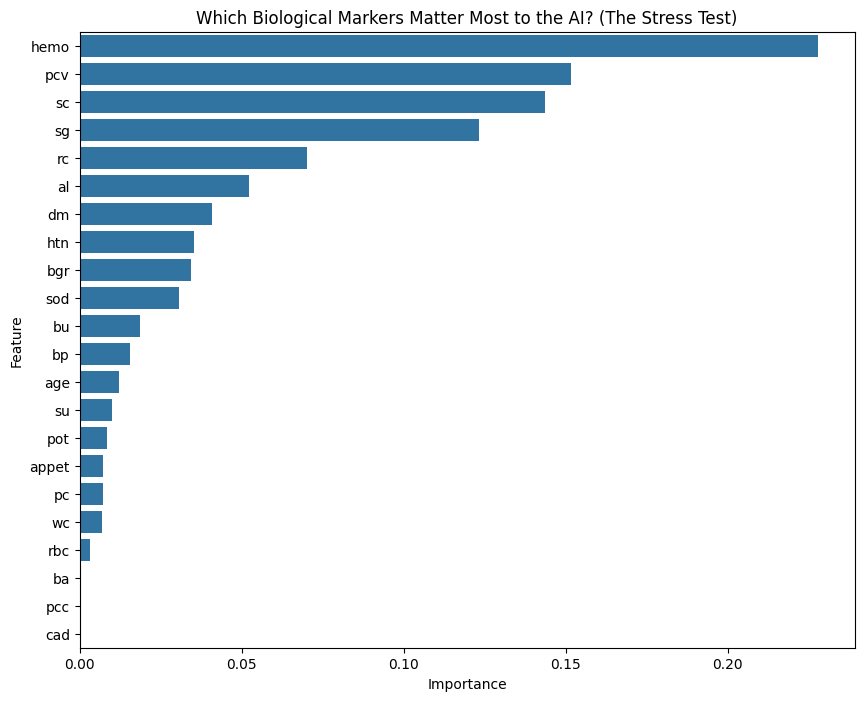

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extracting the Feature Importances
importances = model.feature_importances_
feature_names = x.columns

# 2. Organize them into a sorted table
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Visualize the "Biological Logic" of the AI
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Which Biological Markers Matter Most to the AI? (The Stress Test)')
plt.show()

CROSS-CHECKING THE MODEL

In [24]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, x, y, cv=5)

print(f"Scroes for each of the 5 exams: {scores}")
print(f"Average True accuracy: {scores.mean() * 100:.2f}%")

Scroes for each of the 5 exams: [0.9875 1.     0.9625 0.9875 1.    ]
Average True accuracy: 98.75%


In [25]:
sample_patient = x_test.iloc[[5]]
actual_truth = y_test.iloc[5]

prediction = model.predict(sample_patient)[0]
confidence = model.predict_proba(sample_patient)[0]

print("--- Individual Patient X-Ray ---")
print(f"The Truth: Patient is Class {actual_truth} (0=Healthy, 2=CKD)")
print(f"AI Prediction: Class {prediction}")
print(f"AI Confidence: {confidence[0]*100:.1f}% sure it's Healthy, {confidence[1]*100:.1f}% sure it's CKD")

--- Individual Patient X-Ray ---
The Truth: Patient is Class 0 (0=Healthy, 2=CKD)
AI Prediction: Class 0
AI Confidence: 98.0% sure it's Healthy, 2.0% sure it's CKD
